# Adjustability Results

**Adjustability** metric (`src/adjustability.py` → `data/adjustability.parquet`): how much a hitter reshapes his swing by situation, net of pitch location. This notebook shows the leaderboard and visualizes whether adjustability pays off (`src/payoff.py` → `results/payoff.md`).

In [1]:
# Setup: paths + theme shared by the cells below. The leaderboard is rendered by R
# (src/leaderboard_table.R); the payoff coefficient forest plots are parsed from results/payoff.md.
from pathlib import Path
import pandas as pd

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
PLOTS = ROOT / 'results' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

# fivethirtyeight on a white background (grid color set explicitly; FT's default grid is white).
FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]


def plot_path(name):
    """Route a figure filename to its results/plots/<category> subfolder (mirrored in the R
    generator and the other results notebooks)."""
    sub = 'adjustability' if name.startswith('adjustability') else 'predictiveness'
    d = PLOTS / sub
    d.mkdir(parents=True, exist_ok=True)
    return d / name

## Why we must net out pitch location first

Adjustability asks whether a hitter changes his swing *by situation*. The threat to that claim is **pitch location**: where the ball is already dictates the swing, and location is **not evenly distributed across situations** (pitchers work differently with two strikes). So a naive "his swing differs by situation" signal is partly just "he saw different pitches." Two panels establish the confound, which is why the metric residualizes location *before* measuring adjustment:

1. **The swing is set by location** — mean swing geometry varies sharply across the strike zone (location alone explains ~41% of swing length and ~46% of swing tilt).
2. **Location shifts with the situation** — two-strike pitches expand out of the zone's middle.

Location drives the swing *and* moves with the count, so any situation signal measured without controlling location is contaminated by it.

632,203 competitive swings, [2024, 2025]
  location explains 11.7% of bat_speed
  location explains 40.8% of swing_length
  location explains 45.8% of swing_path_tilt


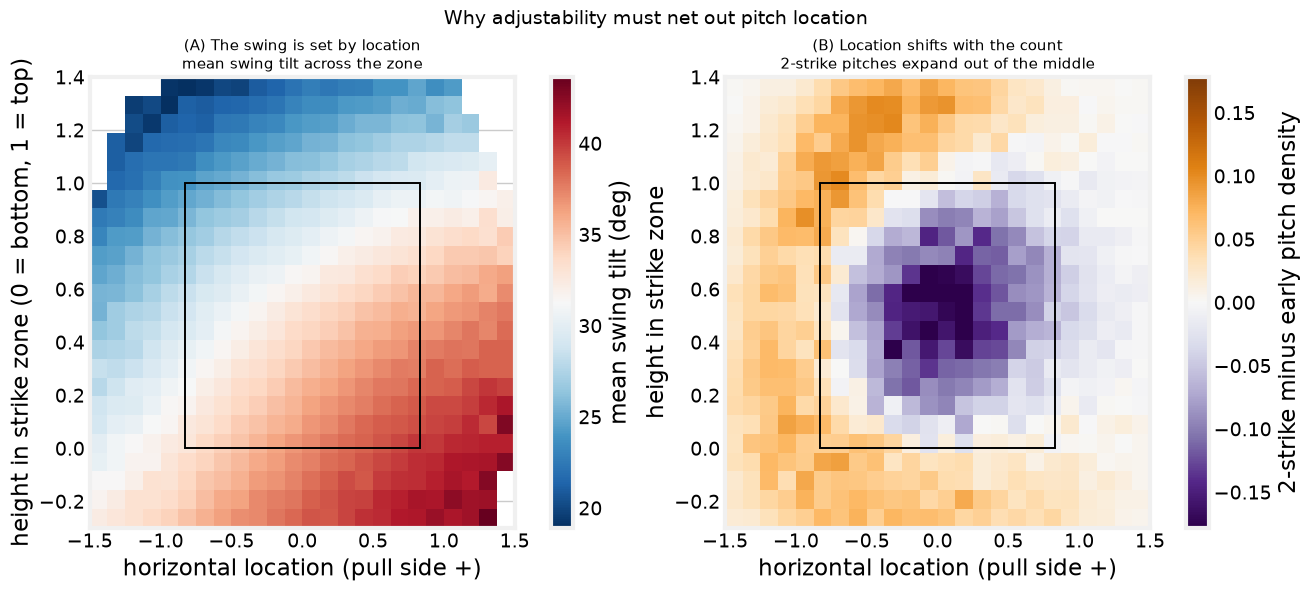

In [2]:
# ---- Defense figure: why the location confound must be controlled ----
# (A) the swing dials are set by pitch location; (B) pitch location shifts with the situation
# (2-strike pitches expand out of the zone's middle). Together: the swing is largely dictated by where
# the pitch is, and where the pitch is depends on the situation -- so a raw "his swing differs by
# situation" signal is confounded by location, which is why the metric nets location out first.
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, str(ROOT / 'src'))
from adjustability import add_context, location_design, DIALS, KEY, SEASONS

cols = (['game_year', 'batter_full_name'] + KEY + ['balls', 'strikes', 'outs_when_up', 'plate_x',
        'plate_z', 'sz_top', 'sz_bot', 'pitch_type', 'on_1b_id', 'on_2b_id', 'on_3b_id'] + DIALS)
df = add_context(pd.read_parquet(DATA / 'swings_model.parquet', columns=cols).query('game_year in @SEASONS'))
print(f'{len(df):,} competitive swings, {SEASONS}')

# how much of each dial does location alone explain, league-wide? (the panel-A headline number)
Lall = location_design(df)
for d in DIALS:
    b, *_ = np.linalg.lstsq(Lall, df[d].to_numpy(float), rcond=None)
    r2 = 1 - ((df[d] - Lall @ b) ** 2).sum() / ((df[d] - df[d].mean()) ** 2).sum()
    print(f'  location explains {r2 * 100:4.1f}% of {d}')

xb = np.linspace(-1.5, 1.5, 25)
yb = np.linspace(-0.3, 1.4, 25)
ZONE = dict(xy=(-0.83, 0.0), width=1.66, height=1.0)   # approx strike zone in (px, normalized pz)

with plt.style.context(FT):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.8), constrained_layout=True)

    # (A) mean swing tilt across the zone -- location sets the swing geometry
    zdial = 'swing_path_tilt'
    xi, yi = np.digitize(df.px, xb) - 1, np.digitize(df.pz, yb) - 1
    v = df[zdial].to_numpy(float)
    stat = np.full((len(yb) - 1, len(xb) - 1), np.nan)
    for i in range(len(yb) - 1):
        for j in range(len(xb) - 1):
            m = (xi == j) & (yi == i)
            if m.sum() >= 40:
                stat[i, j] = v[m].mean()
    im = axA.pcolormesh(xb, yb, stat, cmap='RdBu_r', shading='flat')
    axA.add_patch(plt.Rectangle(**ZONE, fill=False, edgecolor='k', lw=1.4))
    fig.colorbar(im, ax=axA, label='mean swing tilt (deg)')
    axA.set_title('(A) The swing is set by location\nmean swing tilt across the zone', fontsize=11)
    axA.set_xlabel('horizontal location (pull side +)')
    axA.set_ylabel('height in strike zone (0 = bottom, 1 = top)')

    # (B) where 2-strike pitches concentrate vs earlier counts (density difference)
    twok, early = df[df.strikes == 2], df[df.strikes < 2]
    H2, _, _ = np.histogram2d(twok.px, twok.pz, bins=[xb, yb], density=True)
    H0, _, _ = np.histogram2d(early.px, early.pz, bins=[xb, yb], density=True)
    diff = (H2 - H0).T
    lim = np.nanpercentile(np.abs(diff), 99)
    im2 = axB.pcolormesh(xb, yb, diff, cmap='PuOr_r', vmin=-lim, vmax=lim, shading='flat')
    axB.add_patch(plt.Rectangle(**ZONE, fill=False, edgecolor='k', lw=1.4))
    fig.colorbar(im2, ax=axB, label='2-strike minus early pitch density')
    axB.set_title('(B) Location shifts with the count\n2-strike pitches expand out of the middle', fontsize=11)
    axB.set_xlabel('horizontal location (pull side +)')
    axB.set_ylabel('height in strike zone')

    fig.suptitle('Why adjustability must net out pitch location', fontsize=14)
    fig.savefig(plot_path('adjustability_location_confound.png'), dpi=130)
    plt.show()

## Adjustability leaderboard (R · gt + headshots)

Rendered with **`gt` + `mlbplotR`** (MLBAM headshots, 538 theme) via `src/leaderboard_table.R`, reading `data/adjustability.parquet`. Colored on the headline **adjustability** (red = high, blue = low) with the domain fixed to the full qualified pool, so Top 10 reads all-red / Bottom 10 all-blue. The **Count axis** and **Pitch axis** columns show where each hitter's adjustability lives (each is that axis's unique contribution, net of the others). The two-strike payoff sits in the count axis.

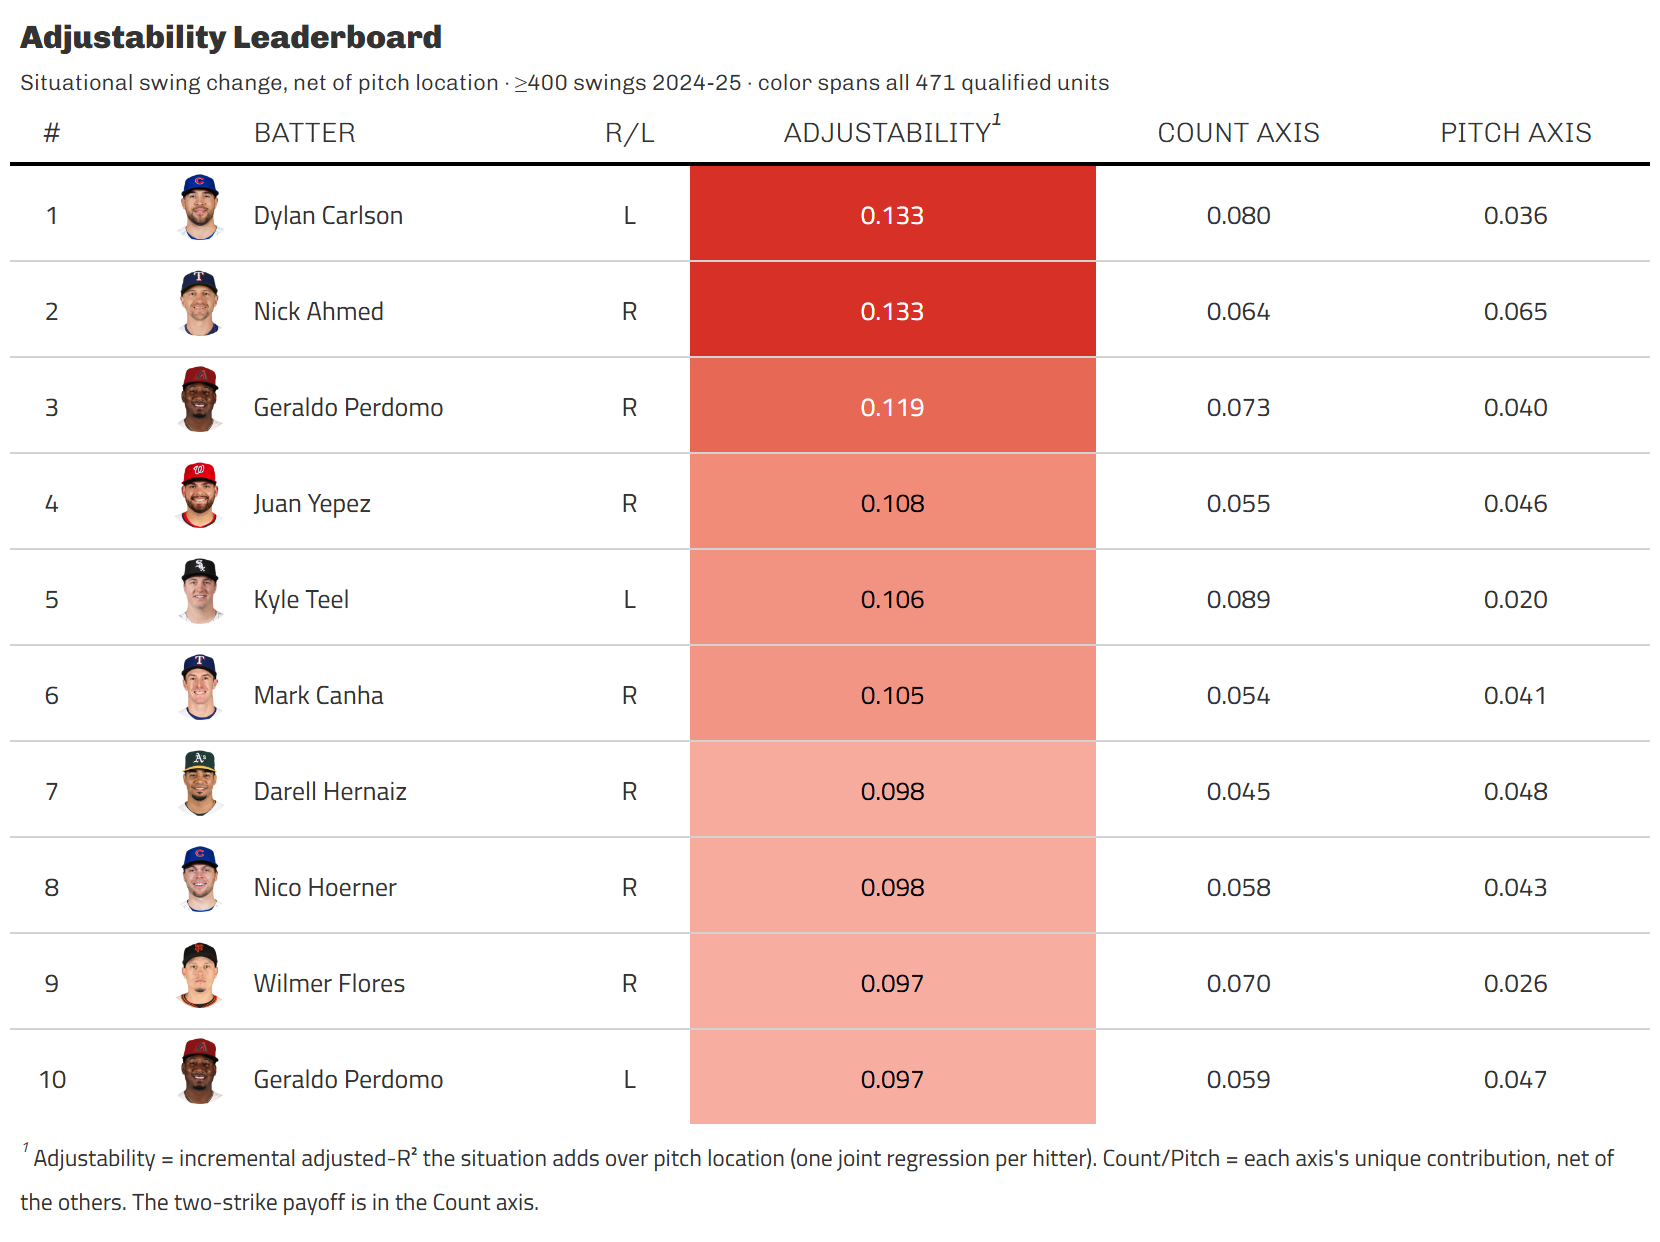

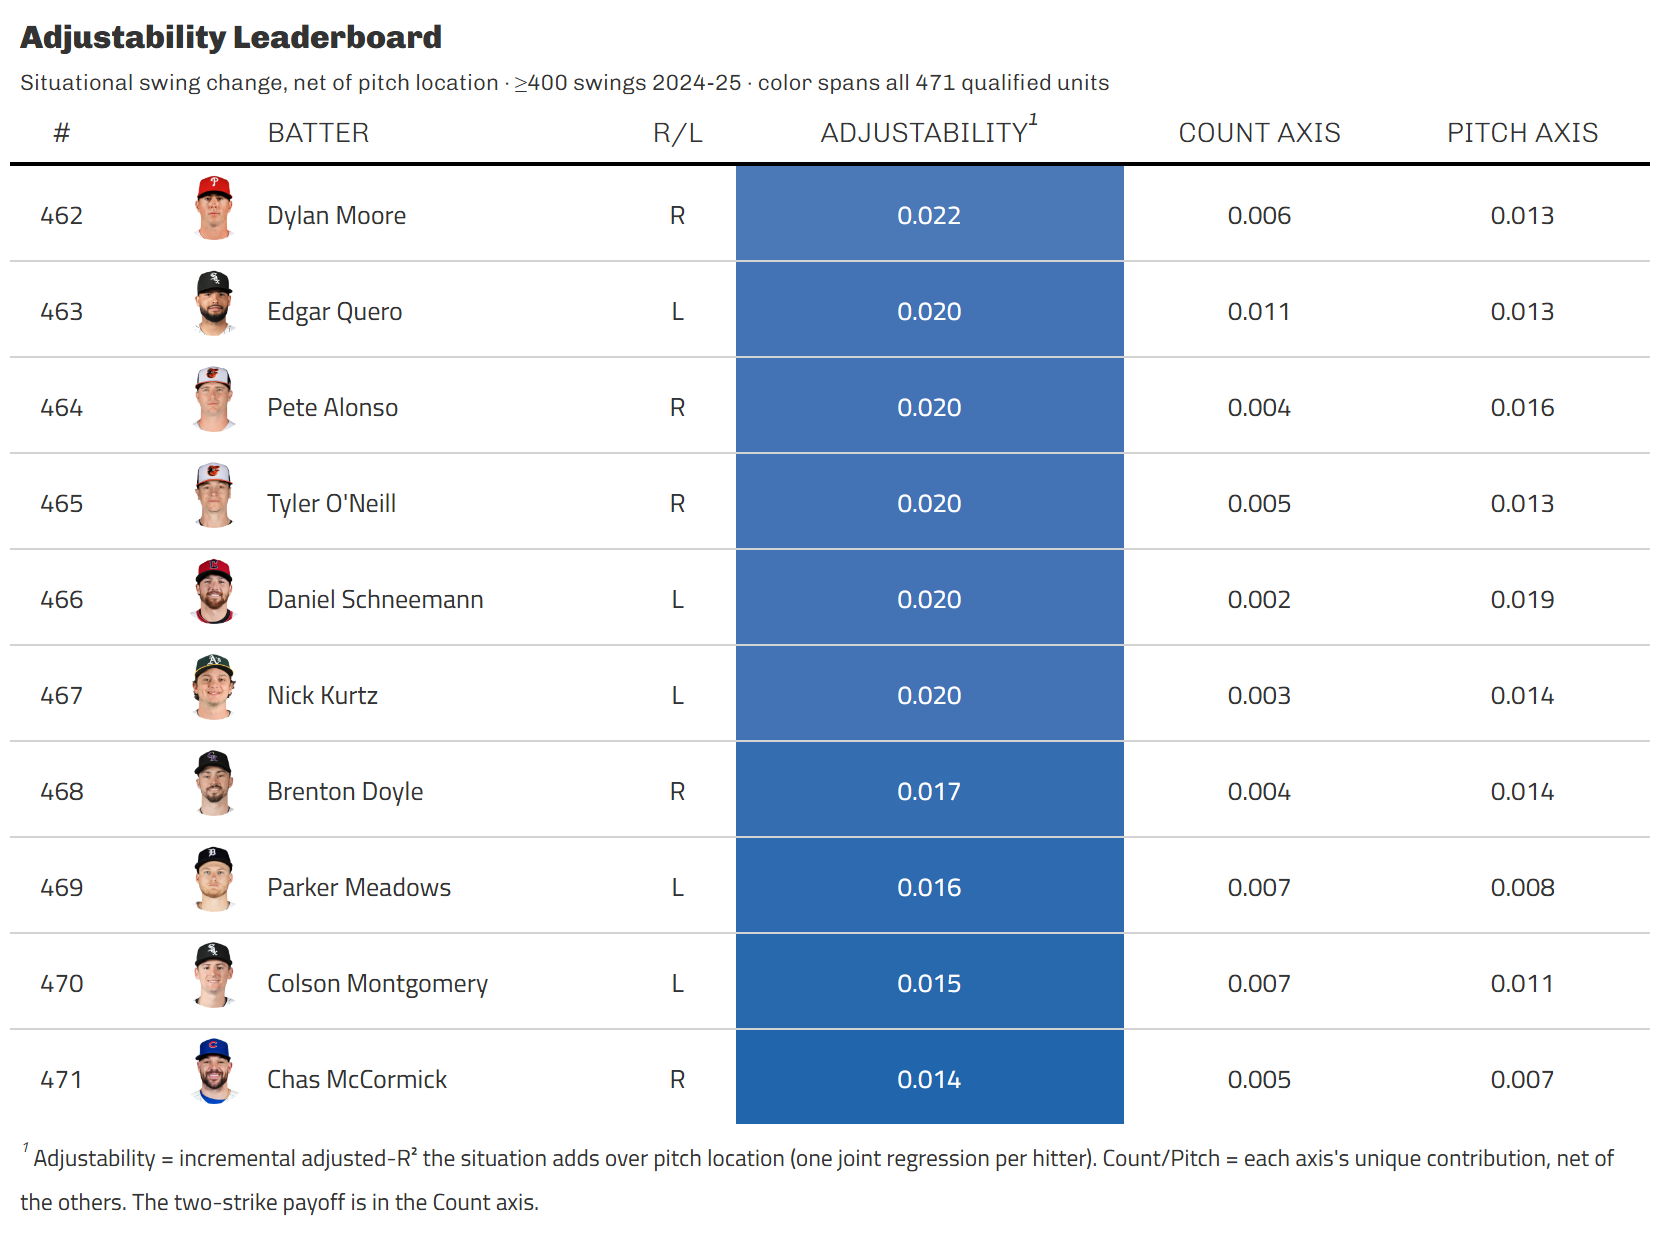

In [3]:
# Adjustability leaderboard via R. Runs src/leaderboard_table.R (which writes
# results/plots/adjustability/*.png) and displays the top/bottom tables inline. Rscript isn't on PATH
# here -> fall back to the R 4.6.0 install.
import subprocess, shutil
from IPython.display import Image, display

RSCRIPT = shutil.which('Rscript') or r'C:\Users\theo.an-yeung\AppData\Local\Programs\R\R-4.6.0\bin\Rscript.exe'
subprocess.run([RSCRIPT, 'src/leaderboard_table.R'], cwd=str(ROOT), check=True)
for png in ['adjustability_leaderboard_gt.png', 'adjustability_bottom_gt.png']:
    display(Image(filename=str(plot_path(png))))

## Payoff-model coefficients (forest plots)

Visualizes the committed output of `src/payoff.py` — the standardized coefficients from `results/payoff.md`, not a recomputation. Each panel is one model: point = standardized β, whiskers = ±1.96·se (95% CI), vertical line at 0. **`adj_count`** — the axis that carries the two-strike payoff — is drawn in Driveline goldenrod; terms significant at p<0.05 are filled, others hollow. The intercept row is dropped (≈0 by construction on standardized inputs).

The story is the **contrast**: two-strike protection loads on `adj_count` (positive on run value, strongly negative on whiffs), while season-wide everything but swing quality / playing time washes out — the foil ruling out 'adjusters are just good hitters'.

parsed models: ['penalty_rv', 'matched_rv', 'penalty_whiff', 'matched_whiff', 'rv_per_swing', 'xwobacon']


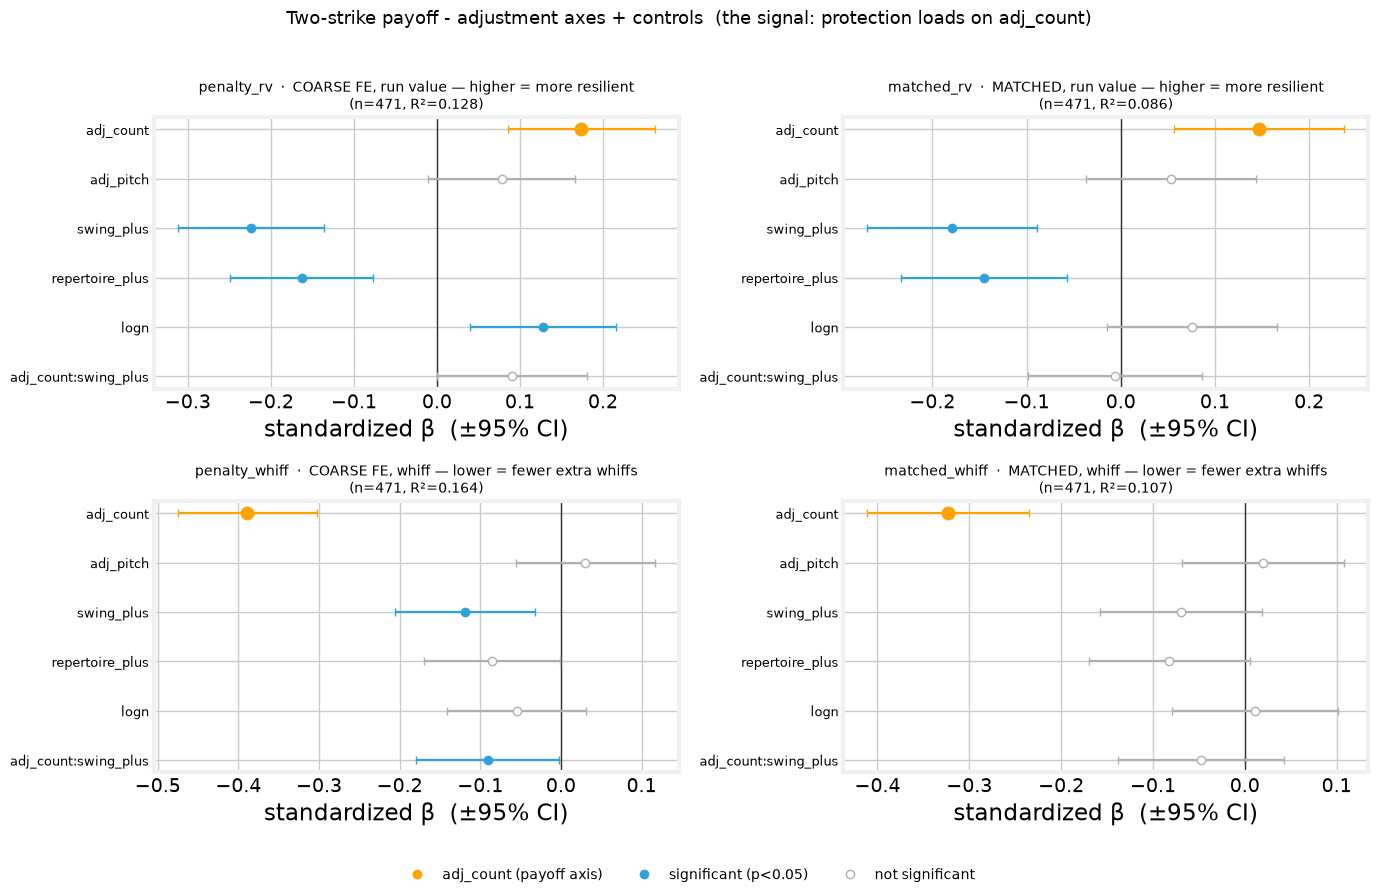

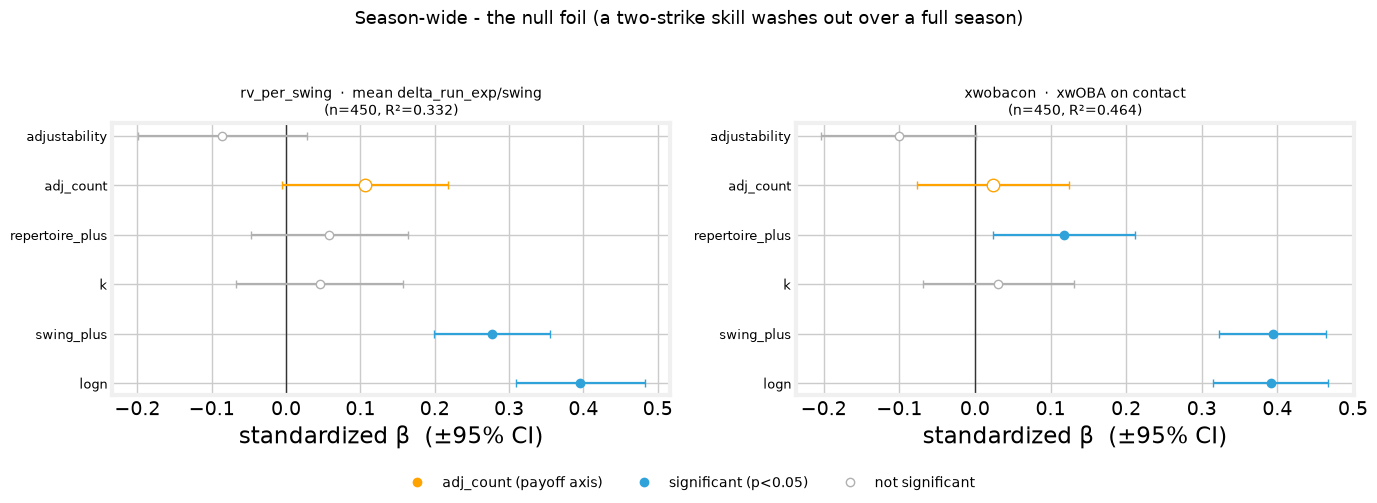

wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\adjustability\adjustability_payoff_twostrike_coeffs.png
wrote C:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\adjustability\adjustability_payoff_season_coeffs.png


In [4]:
# ---- Parse results/payoff.md into per-model coefficient frames, then forest-plot ----
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

GOLD, SIG, NS = '#FFA300', '#30a2da', '#b0b0b0'   # goldenrod = adj_count; blue = other sig; grey = n.s.


def parse_payoff(md_path):
    """Strict parser: {outcome: dict(df, n, r2, desc)}. Each `### <outcome> ... n=..., R2=...`
    section is a std-coefficient pipe-table. Raises if a tagged section has no table."""
    text = md_path.read_text(encoding='utf-8')
    blocks, parts = {}, re.split(r'^### (.+)$', text, flags=re.M)
    for title, body in zip(parts[1::2], parts[2::2]):
        m = re.search(r'n=(\d+),\s*R²=([\d.]+)', title)
        if not m:                                   # e.g. the zero-order-correlations section
            continue
        rows = [ln for ln in body.splitlines() if ln.strip().startswith('|')]
        if len(rows) < 3:
            raise ValueError(f'no coefficient table under section: {title}')
        header = [c.strip() for c in rows[0].strip('|').split('|')]
        recs = [dict(zip(header, [c.strip() for c in ln.strip('|').split('|')])) for ln in rows[2:]]
        df = pd.DataFrame(recs)
        for c in ['std_beta', 'se', 't', 'p']:
            df[c] = df[c].astype(float)
        desc = re.search(r'\((.*?)\)', title)
        blocks[title.split()[0]] = dict(df=df[df.term != 'intercept'].reset_index(drop=True),
                                         n=int(m.group(1)), r2=float(m.group(2)),
                                         desc=desc.group(1) if desc else '')
    return blocks


def forest(ax, key, blocks):
    b = blocks[key]
    d = b['df'].iloc[::-1].reset_index(drop=True)   # first listed term at the top
    for i, row in d.iterrows():
        sig, is_ac = row['p'] < 0.05, row['term'] == 'adj_count'
        color = GOLD if is_ac else (SIG if sig else NS)
        ax.errorbar(row['std_beta'], i, xerr=1.96 * row['se'], fmt='o', color=color,
                    markersize=9 if is_ac else 6, markerfacecolor=color if sig else 'white',
                    markeredgecolor=color, capsize=3, lw=1.6, zorder=3 if is_ac else 2)
    ax.axvline(0, color='#333333', lw=1, zorder=1)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels(d['term'], fontsize=9)
    ax.set_title(f"{key}  ·  {b['desc']}\n(n={b['n']}, R²={b['r2']:.3f})", fontsize=10)
    ax.set_xlabel('standardized β  (±95% CI)')


blocks = parse_payoff(ROOT / 'results' / 'payoff.md')
LEGEND = [Line2D([0], [0], marker='o', color=GOLD, lw=0, label='adj_count (payoff axis)'),
          Line2D([0], [0], marker='o', color=SIG, lw=0, label='significant (p<0.05)'),
          Line2D([0], [0], marker='o', color=NS, markerfacecolor='white', lw=0, label='not significant')]
print('parsed models:', list(blocks))

# Figure 1 - the four two-strike models (the signal)
with plt.style.context(FT):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, key in zip(axes.flat, ['penalty_rv', 'matched_rv', 'penalty_whiff', 'matched_whiff']):
        forest(ax, key, blocks)
    fig.suptitle('Two-strike payoff - adjustment axes + controls  (the signal: protection loads on adj_count)',
                 fontsize=13)
    fig.legend(handles=LEGEND, loc='lower center', ncol=3, frameon=False, fontsize=10)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    fig.savefig(plot_path('adjustability_payoff_twostrike_coeffs.png'), dpi=130)
    plt.show()

# Figure 2 - the two season-wide models (the null foil)
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, key in zip(axes, ['rv_per_swing', 'xwobacon']):
        forest(ax, key, blocks)
    fig.suptitle('Season-wide - the null foil (a two-strike skill washes out over a full season)',
                 fontsize=13)
    fig.legend(handles=LEGEND, loc='lower center', ncol=3, frameon=False, fontsize=10)
    fig.tight_layout(rect=[0, 0.06, 1, 0.95])
    fig.savefig(plot_path('adjustability_payoff_season_coeffs.png'), dpi=130)
    plt.show()
print('wrote', plot_path('adjustability_payoff_twostrike_coeffs.png'))
print('wrote', plot_path('adjustability_payoff_season_coeffs.png'))

## Adjustability is not just “good hitting” — the season-wide null

The two-strike payoff only means something if adjustability isn't just a stand-in for being a good hitter. The check: **if adjustability were simply a proxy for hitting well, it would predict season-long production** — and it doesn't. These two panels share the same y-axis (season run value per swing) so the contrast is direct:

- **Left — the power check.** Swing *quality* (Swing+) tracks season production steeply, so the outcome is clearly predictable and the test has power.
- **Right — adjustability.** Against that same outcome it is essentially flat. Adjusters do not out-produce over a full season.

So adjustability isn't general hitting quality wearing a different hat; its payoff (previous figure) is a targeted two-strike skill, exercised on too few pitches to move a season line.

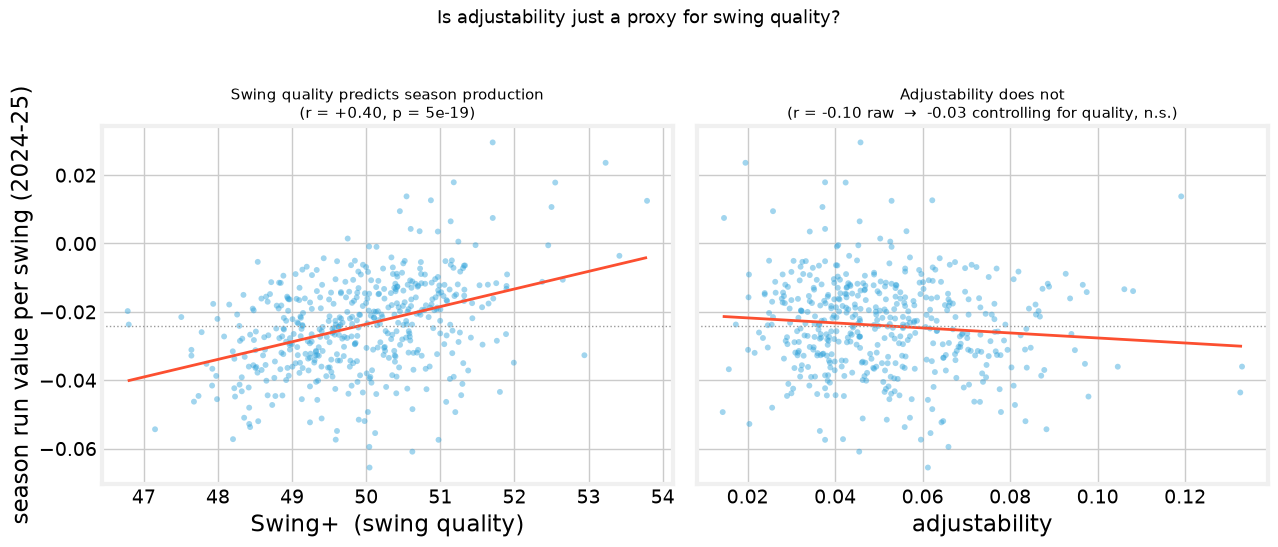

quality  r = +0.395 (p=4.5e-19);  adjustability raw r = -0.099, partial r|quality = -0.031 (p=0.50)


In [5]:
# ---- Season-wide null: adjustability is not a proxy for hitting well ----
# Same outcome (season run value / swing) on both panels. LEFT: swing quality predicts it (power
# check). RIGHT: adjustability does not -- and the faint raw negative slope vanishes once we control
# for swing quality (partial r), matching the season-wide regression's null. Per (batter, stand),
# 2024-25, the 471 qualified units.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

KEY = ['batter_id', 'batter_stand']
SEASONS = [2024, 2025]

adj = pd.read_parquet(DATA / 'adjustability.parquet', columns=KEY + ['adjustability'])
swp = pd.read_parquet(DATA / 'xrv_swings.parquet', columns=KEY + ['game_year', 'xrv_grade'])
swp = (swp[swp.game_year.isin(SEASONS)].groupby(KEY)['xrv_grade'].mean()
       .rename('swing_plus').reset_index())
rv = pd.read_parquet(DATA / 'swings_model.parquet', columns=KEY + ['game_year', 'delta_run_exp'])
rv = (rv[rv.game_year.isin(SEASONS)].groupby(KEY)['delta_run_exp'].mean()
      .rename('rv_per_swing').reset_index())
d = adj.merge(swp, on=KEY).merge(rv, on=KEY)


def fit_resid(y, x):
    b1, b0 = np.polyfit(x, y, 1)
    return y - (b0 + b1 * x)

# partial correlation of adjustability with season RV, controlling for swing quality
r_raw, _ = stats.pearsonr(d['adjustability'], d['rv_per_swing'])
r_part, p_part = stats.pearsonr(fit_resid(d['adjustability'].values, d['swing_plus'].values),
                                fit_resid(d['rv_per_swing'].values, d['swing_plus'].values))
r_q, p_q = stats.pearsonr(d['swing_plus'], d['rv_per_swing'])

titles = ['Swing quality predicts season production\n'
          f'(r = {r_q:+.2f}, p = {p_q:.0e})',
          'Adjustability does not\n'
          f'(r = {r_raw:+.2f} raw  →  {r_part:+.2f} controlling for quality, n.s.)']
with plt.style.context(FT):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)
    for ax, col, title in zip(axes, ['swing_plus', 'adjustability'], titles):
        b1, b0 = np.polyfit(d[col], d['rv_per_swing'], 1)
        xs = np.array([d[col].min(), d[col].max()])
        ax.scatter(d[col], d['rv_per_swing'], s=18, alpha=.45, color='#30a2da', edgecolor='none')
        ax.plot(xs, b0 + b1 * xs, color='#fc4f30', lw=2)
        ax.axhline(d['rv_per_swing'].mean(), color='#999999', lw=1, ls=':')
        ax.set_title(title, fontsize=11)
    axes[0].set_xlabel('Swing+  (swing quality)')
    axes[1].set_xlabel('adjustability')
    axes[0].set_ylabel('season run value per swing (2024-25)')
    fig.suptitle('Is adjustability just a proxy for swing quality?',
                 fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(plot_path('adjustability_season_null.png'), dpi=130)
    plt.show()
print(f'quality  r = {r_q:+.3f} (p={p_q:.1e});  adjustability raw r = {r_raw:+.3f}, '
      f'partial r|quality = {r_part:+.3f} (p={p_part:.2f})')

## Where does adjustability live? — count axis vs pitch axis

Each axis is its **unique** contribution to the swing, net of pitch location and the other axes (so `adj_count` holds pitch type fixed). This scatter shows the count and pitch axes are only weakly related — they're distinct skills, and the two-strike payoff lives entirely in **adj_count**. (Under the v4 metric the headline `adjustability` is count-led, not pitch-dominated — a hitter high on the count axis is the one who protects at two strikes.)

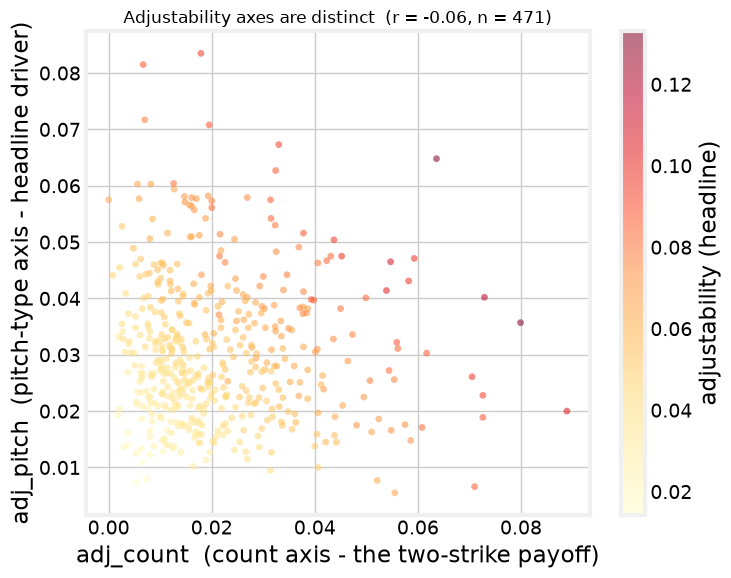

adj_count vs adj_pitch: r = -0.056, n = 471


In [6]:
# adj_count vs adj_pitch, colored by the headline adjustability. Weak relationship = the two axes
# are distinct skills; the payoff (two-strike protection) is the count axis, the headline is pitch.
import numpy as np
import matplotlib.pyplot as plt

adj = pd.read_parquet(DATA / 'adjustability.parquet',
                      columns=['label', 'batter_stand', 'adjustability', 'adj_count', 'adj_pitch'])
r = np.corrcoef(adj['adj_count'], adj['adj_pitch'])[0, 1]
with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(7.5, 6))
    sc = ax.scatter(adj['adj_count'], adj['adj_pitch'], s=24, alpha=.55,
                    c=adj['adjustability'], cmap='YlOrRd', edgecolor='none')
    ax.set_xlabel('adj_count  (count axis - the two-strike payoff)')
    ax.set_ylabel('adj_pitch  (pitch-type axis - headline driver)')
    ax.set_title(f'Adjustability axes are distinct  (r = {r:.2f}, n = {len(adj)})', fontsize=12)
    fig.colorbar(sc, label='adjustability (headline)')
    fig.tight_layout()
    fig.savefig(plot_path('adjustability_axes_scatter.png'), dpi=130)
    plt.show()
print(f'adj_count vs adj_pitch: r = {r:.3f}, n = {len(adj)}')